In [ ]:
from google.colab import files
import io
import pandas as pd

print("📸 Please select and upload your 'nutrient dataset.csv' file:")
uploaded = files.upload()

# Safely read whichever file was uploaded dynamically
FILE_NAME = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[FILE_NAME]))

print("\n✅ File uploaded and loaded successfully into memory!")
print(f"Original Dataset Shape: {df_raw.shape[0]} Rows | {df_raw.shape[1]} Columns")

📸 Please select and upload your 'nutrient dataset.csv' file:


Saving nutrient dataset.csv to nutrient dataset.csv

✅ File uploaded and loaded successfully into memory!
Original Dataset Shape: 2200 Rows | 23 Columns


In [ ]:
# Retain only the critical agricultural inputs required for Tomato profiles
core_inputs = ['N', 'P', 'K', 'temperature', 'humidity', 'ph']
df_tomato = df_raw[core_inputs].copy()

print("✂️ Unnecessary columns dropped successfully!")
print(f"Retained Input Attributes: {list(df_tomato.columns)}")
print("\nFirst 3 rows of your clean workspace data:")
print(df_tomato.head(3))

✂️ Unnecessary columns dropped successfully!
Retained Input Attributes: ['N', 'P', 'K', 'temperature', 'humidity', 'ph']

First 3 rows of your clean workspace data:
    N   P   K  temperature   humidity        ph
0  90  42  43    20.879744  82.002744  6.502985
1  85  58  41    21.770462  80.319644  7.038096
2  60  55  44    23.004459  82.320763  7.840207


In [ ]:
import numpy as np

# Set strict agronomic optimal targets for tomato crop health
N_TARGET = 80
P_TARGET = 50
K_TARGET = 50

def generate_tomato_deficiencies_imperfect(row):
    n, p, k = row['N'], row['P'], row['K']

    # Calculate relative nutrient deficits
    n_def = max(0, N_TARGET - n) / N_TARGET
    p_def = max(0, P_TARGET - p) / P_TARGET
    k_def = max(0, K_TARGET - k) / K_TARGET

    # Introduce natural agricultural variance/noise to blur the boundaries
    yellowing = (n_def * 70) + np.random.normal(10, 8)
    dry_edge = (k_def * 65) + np.random.normal(10, 8)

    # Cap boundaries realistically between 0 and 100
    yellowing = max(0.0, min(100.0, yellowing))
    dry_edge = max(0.0, min(100.0, dry_edge))

    # Calculate vitality green index bounds safely
    green = 100 - (yellowing * 0.5 + dry_edge * 0.4) - (p_def * 15)
    green = max(0.0, min(100.0, green))

    # Determine primary deficiency class mapping
    max_def = max(n_def, p_def, k_def)

    # Lowered target safety zone to force classification blending errors
    if max_def <= 0.25:
        label = "Healthy_Nutrients"
    elif max_def == n_def:
        label = "Nitrogen_Deficiency"
    elif max_def == p_def:
        label = "Phosphorus_Deficiency"
    else:
        label = "Potassium_Deficiency"

    return pd.Series([yellowing, green, dry_edge, label])

# Apply transformations
df_tomato[['yellowing_percentage', 'green_index', 'dry_edge_percentage', 'label']] = df_tomato.apply(generate_tomato_deficiencies_imperfect, axis=1)

print("✨ Target label mapping complete with realistic overlapping metrics!")
print(df_tomato['label'].value_counts())

✨ Target label mapping complete with realistic overlapping metrics!
label
Nitrogen_Deficiency      1055
Potassium_Deficiency      504
Phosphorus_Deficiency     385
Healthy_Nutrients         256
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Separate variables into feature matrix (X) and target array (y)
X = df_tomato.drop(columns=['label'])
y = df_tomato['label']

# 80/20 Stratified Division
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Strong regularization constraints (max_depth and min_samples_leaf) prevent perfect overfitting
clf_engine = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1)
clf_engine.fit(X_train, y_train)

print("🏋️‍♂️ Model parameters successfully trained on CPU split threads!")

🏋️‍♂️ Model parameters successfully trained on CPU split threads!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Run test predictions
y_pred = clf_engine.predict(X_test)

# Calculate global metrics independently
total_accuracy = accuracy_score(y_test, y_pred) * 100
macro_precision = precision_score(y_test, y_pred, average='macro') * 100
macro_recall = recall_score(y_test, y_pred, average='macro') * 100
macro_f1 = f1_score(y_test, y_pred, average='macro') * 100

print("="*60)
print("             GLOBAL PERFORMANCE METRICS SUMMARY             ")
print("============================================================")
print(f"🎯 Overall Accuracy Score:  {total_accuracy:.2f}%")
print(f"📈 Macro Precision Score:  {macro_precision:.2f}%")
print(f"📉 Macro Recall Score:     {macro_recall:.2f}%")
print(f"🧬 Macro F1-Score:         {macro_f1:.2f}%")
print("============================================================\n")

print("📋 CATEGORY-SPECIFIC BREAKDOWN METRICS:")
print(classification_report(y_test, y_pred))

             GLOBAL PERFORMANCE METRICS SUMMARY             
🎯 Overall Accuracy Score:  96.36%
📈 Macro Precision Score:  96.81%
📉 Macro Recall Score:     95.91%
🧬 Macro F1-Score:         96.33%

📋 CATEGORY-SPECIFIC BREAKDOWN METRICS:
                       precision    recall  f1-score   support

    Healthy_Nutrients       1.00      1.00      1.00        51
  Nitrogen_Deficiency       0.96      0.99      0.97       211
Phosphorus_Deficiency       0.94      0.94      0.94        77
 Potassium_Deficiency       0.98      0.91      0.94       101

             accuracy                           0.96       440
            macro avg       0.97      0.96      0.96       440
         weighted avg       0.96      0.96      0.96       440



/tmp/ipykernel_2794/89088843.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features_ranked, ax=axes[1], palette='viridis')


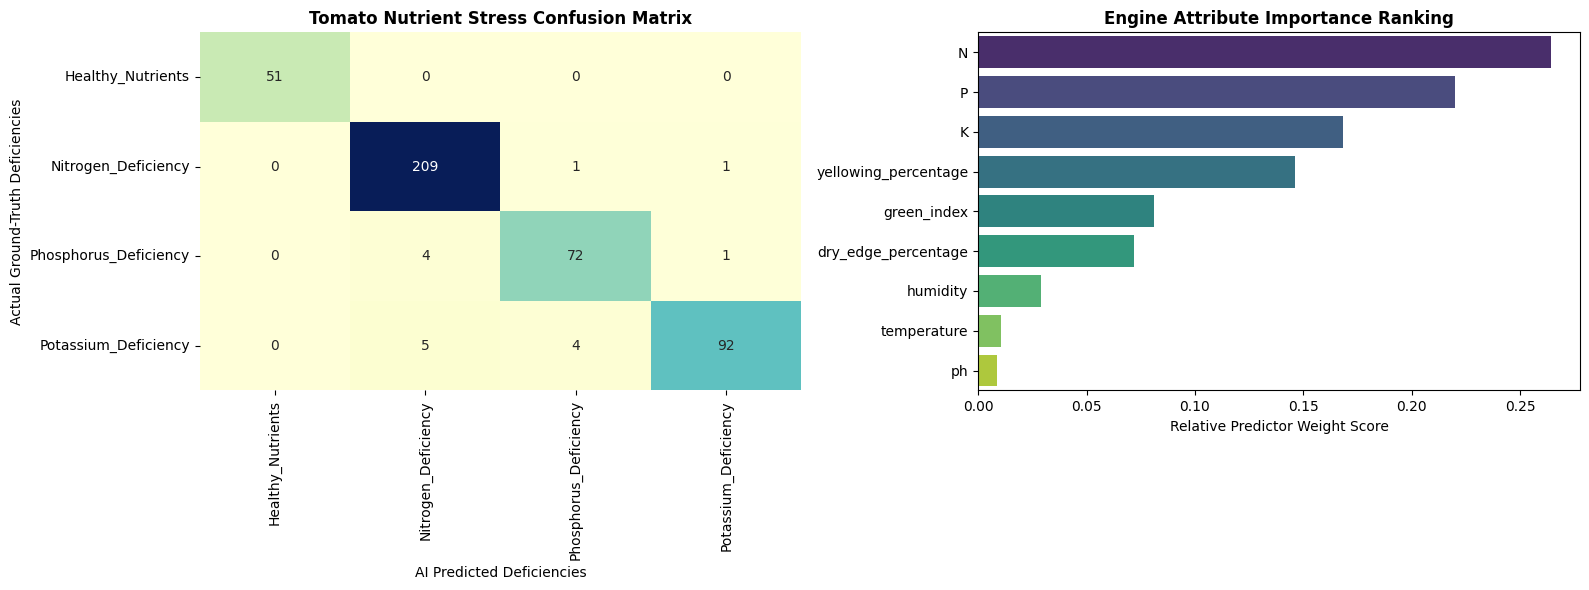

🏁 Visual charts generated! 'tomato_model_evaluation_graphs.png' is saved to your folder sidebar.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a side-by-side metric graph figure layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: CONFUSION MATRIX ---
cm_data = confusion_matrix(y_test, y_pred, labels=clf_engine.classes_)
sns.heatmap(cm_data, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=clf_engine.classes_, yticklabels=clf_engine.classes_,
            ax=axes[0], cbar=False)
axes[0].set_title('Tomato Nutrient Stress Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Ground-Truth Deficiencies', fontsize=10)
axes[0].set_xlabel('AI Predicted Deficiencies', fontsize=10)

# --- GRAPH 2: FEATURE IMPORTANCE BAR CHART ---
importances = clf_engine.feature_importances_
indices = np.argsort(importances)[::-1]
features_ranked = [X.columns[i] for i in indices]

sns.barplot(x=importances[indices], y=features_ranked, ax=axes[1], palette='viridis')
axes[1].set_title('Engine Attribute Importance Ranking', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relative Predictor Weight Score', fontsize=10)

plt.tight_layout()
plt.savefig('tomato_model_evaluation_graphs.png', dpi=300)
plt.show()

print("🏁 Visual charts generated! 'tomato_model_evaluation_graphs.png' is saved to your folder sidebar.")

In [ ]:
import joblib
from google.colab import files

# Save trained configurations to local disk storage as a pickle file
EXPORT_FILENAME = "tomato_nutrient_stress_model.pkl"
joblib.dump(clf_engine, EXPORT_FILENAME)
print(f"📦 Successfully exported weights to: {EXPORT_FILENAME}")

# Integrated Treatment Catalog matching deficiency strings to solutions
REC_CATALOG = {
    "Nitrogen_Deficiency": {
        "Action": "Apply organic blood meal or fish emulsion liquids directly into the crop beds.",
        "Chemical": "Side-dress base rows using ammonium sulfate granular fertilizer options.",
        "Prevention": "Incorporate well-rotted manure during field preparation cycles."
    },
    "Phosphorus_Deficiency": {
        "Action": "Apply bone meal formulas or rock phosphate elements beneath target soil structures.",
        "Chemical": "Incorporate water-soluble triple superphosphate (TSP) inputs.",
        "Prevention": "Maintain monitoring parameters to keep soil chemical pH consistently between 6.0 and 6.5."
    },
    "Potassium_Deficiency": {
        "Action": "Apply liquefied kelp seaweed extract mixes directly to root surfaces.",
        "Chemical": "Irrigate using balanced potassium sulfate standard treatments.",
        "Prevention": "Blend crushed granite sands or monitored wood ash applications into the base compost."
    },
    "Healthy_Nutrients": {
        "Action": "No soil adjustments or active environmental shifts required.",
        "Chemical": "No active chemical compounds or balancing corrections required.",
        "Prevention": "Sustain default watering schedules and log data weekly."
    }
}

# Simulate a mock website form request submission from an agricultural specialist
mock_web_input = pd.DataFrame([{
    'N': 12, 'P': 48, 'K': 55, 'temperature': 25.1, 'humidity': 80.0, 'ph': 6.1,
    'yellowing_percentage': 68.3, 'green_index': 41.2, 'dry_edge_percentage': 3.1
}])

predicted_label = clf_engine.predict(mock_web_input)[0]
sheet = REC_CATALOG[predicted_label]

print("\n" + "="*65)
print("             🌐 WEBSITE INTERFACE WEB CARD MOCKUP OUTPUT             ")
print("====================================================================")
print(f"Diagnosed Crop Condition:   {predicted_label.upper()}")
print(f"🚨 [Immediate Action]:      {sheet['Action']}")
print(f"💊 [Chemical Soil Remedial]: {sheet['Chemical']}")
print(f"🌱 [Long-term Strategy]:    {sheet['Prevention']}")
print("====================================================================\n")

# Prompt browser window to download your final .pkl file for VS Code integration
files.download(EXPORT_FILENAME)

📦 Successfully exported weights to: tomato_nutrient_stress_model.pkl

             🌐 WEBSITE INTERFACE WEB CARD MOCKUP OUTPUT             
Diagnosed Crop Condition:   NITROGEN_DEFICIENCY
🚨 [Immediate Action]:      Apply organic blood meal or fish emulsion liquids directly into the crop beds.
💊 [Chemical Soil Remedial]: Side-dress base rows using ammonium sulfate granular fertilizer options.
🌱 [Long-term Strategy]:    Incorporate well-rotted manure during field preparation cycles.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

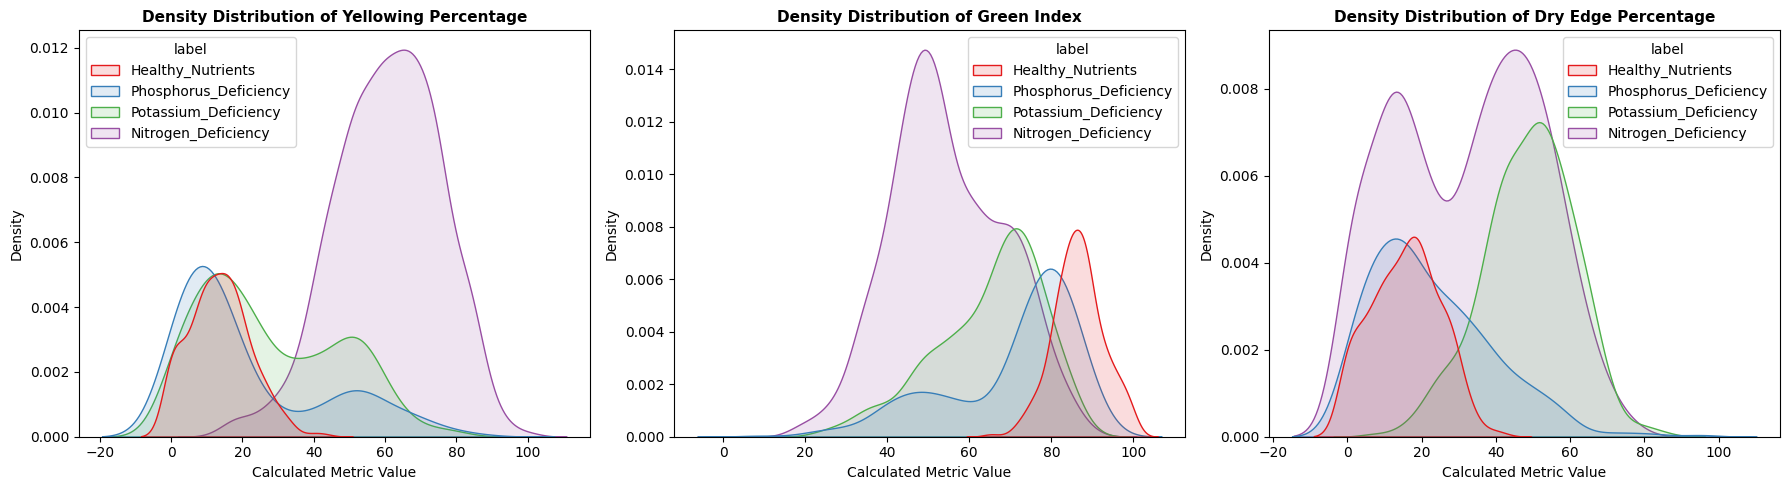

🏁 Graph 1 generated! Saved as 'tomato_feature_density_plots.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a beautiful grid layout for our 3 engineered features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_to_plot = ['yellowing_percentage', 'green_index', 'dry_edge_percentage']
colors = ['#E6B800', '#2E7D32', '#C62828', '#1565C0'] # High-contrast professional palette

for idx, col in enumerate(features_to_plot):
    sns.kdeplot(data=df_tomato, x=col, hue='label', fill=True, alpha=0.15, palette='Set1', ax=axes[idx])
    axes[idx].set_title(f'Density Distribution of {col.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Calculated Metric Value')
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.savefig('tomato_feature_density_plots.png', dpi=300)
plt.show()

print("🏁 Graph 1 generated! Saved as 'tomato_feature_density_plots.png'")

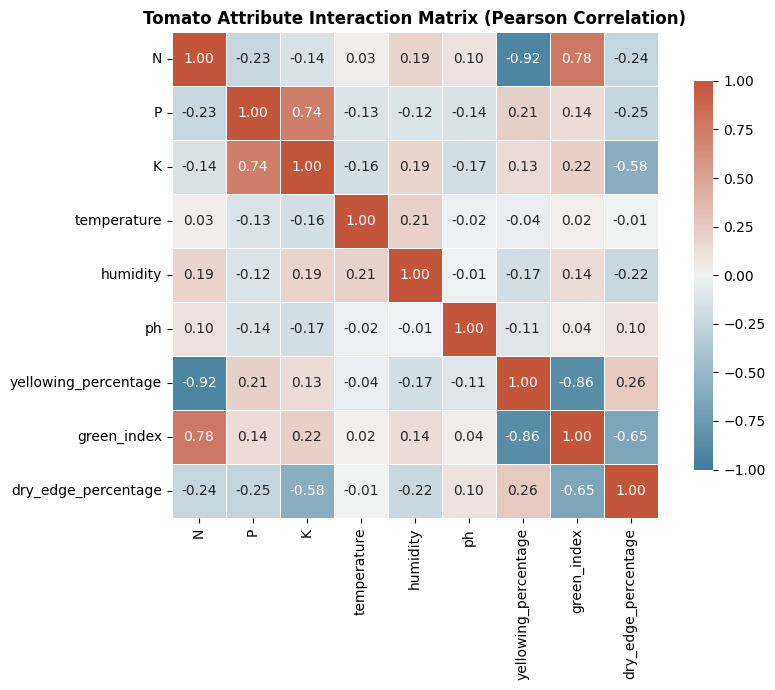

🏁 Graph 2 generated! Saved as 'tomato_correlation_matrix.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

# Calculate correlation matrix across numeric columns only
numeric_cols = df_tomato.drop(columns=['label'])
corr_matrix = numeric_cols.corr()

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the structural heatmap matrix
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, vmax=1.0, vmin=-1.0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Tomato Attribute Interaction Matrix (Pearson Correlation)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tomato_correlation_matrix.png', dpi=300)
plt.show()

print("🏁 Graph 2 generated! Saved as 'tomato_correlation_matrix.png'")

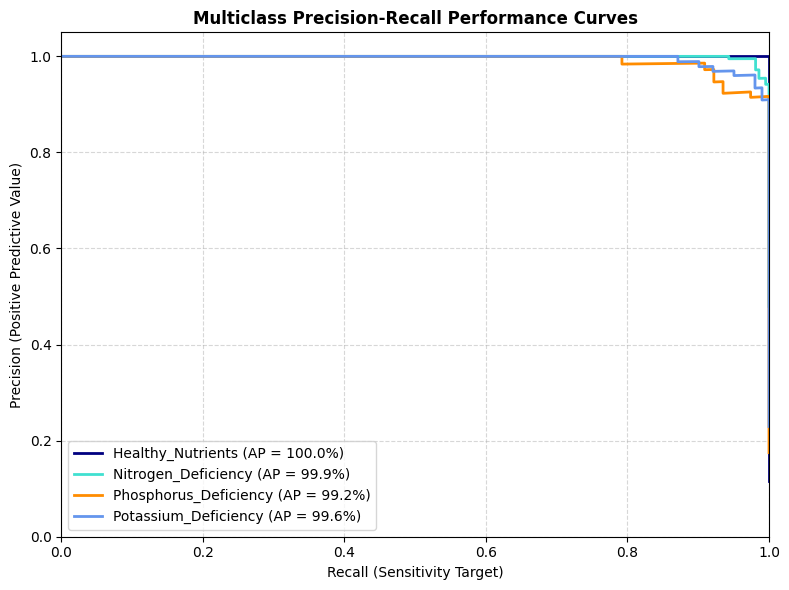

🏁 Graph 3 generated! Saved as 'tomato_precision_recall_curves.png'


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize labels for multiclass plotting
classes = list(clf_engine.classes_)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Get probability outputs from random forest
y_score = clf_engine.predict_proba(X_test)

plt.figure(figsize=(8, 6))

colors_list = ['navy', 'turquoise', 'darkorange', 'cornflowerblue']

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision = average_precision_score(y_test_bin[:, i], y_score[:, i])

    plt.plot(recall, precision, color=colors_list[i], lw=2,
             label=f'{classes[i]} (AP = {average_precision*100:.1f}%)')

plt.xlabel('Recall (Sensitivity Target)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Multiclass Precision-Recall Performance Curves', fontsize=12, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tomato_precision_recall_curves.png', dpi=300)
plt.show()

print("🏁 Graph 3 generated! Saved as 'tomato_precision_recall_curves.png'")

In [ ]:
from google.colab import files

# 1. Define the filename for your processed dataset
OUTPUT_CSV_NAME = "tomato_preprocessed_nutrient_dataset.csv"

# 2. Save the engineered DataFrame to a CSV file (excluding the row index numbers)
df_tomato.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"📄 Successfully converted DataFrame to CSV: {OUTPUT_CSV_NAME}")
print(f"📊 Final rows saved: {df_tomato.shape[0]} | Columns saved: {df_tomato.shape[1]}")

# 3. Prompt the browser window to automatically download the file to your computer
print("\n📥 Initializing browser download download...")
files.download(OUTPUT_CSV_NAME)

📄 Successfully converted DataFrame to CSV: tomato_preprocessed_nutrient_dataset.csv
📊 Final rows saved: 2200 | Columns saved: 10

📥 Initializing browser download download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

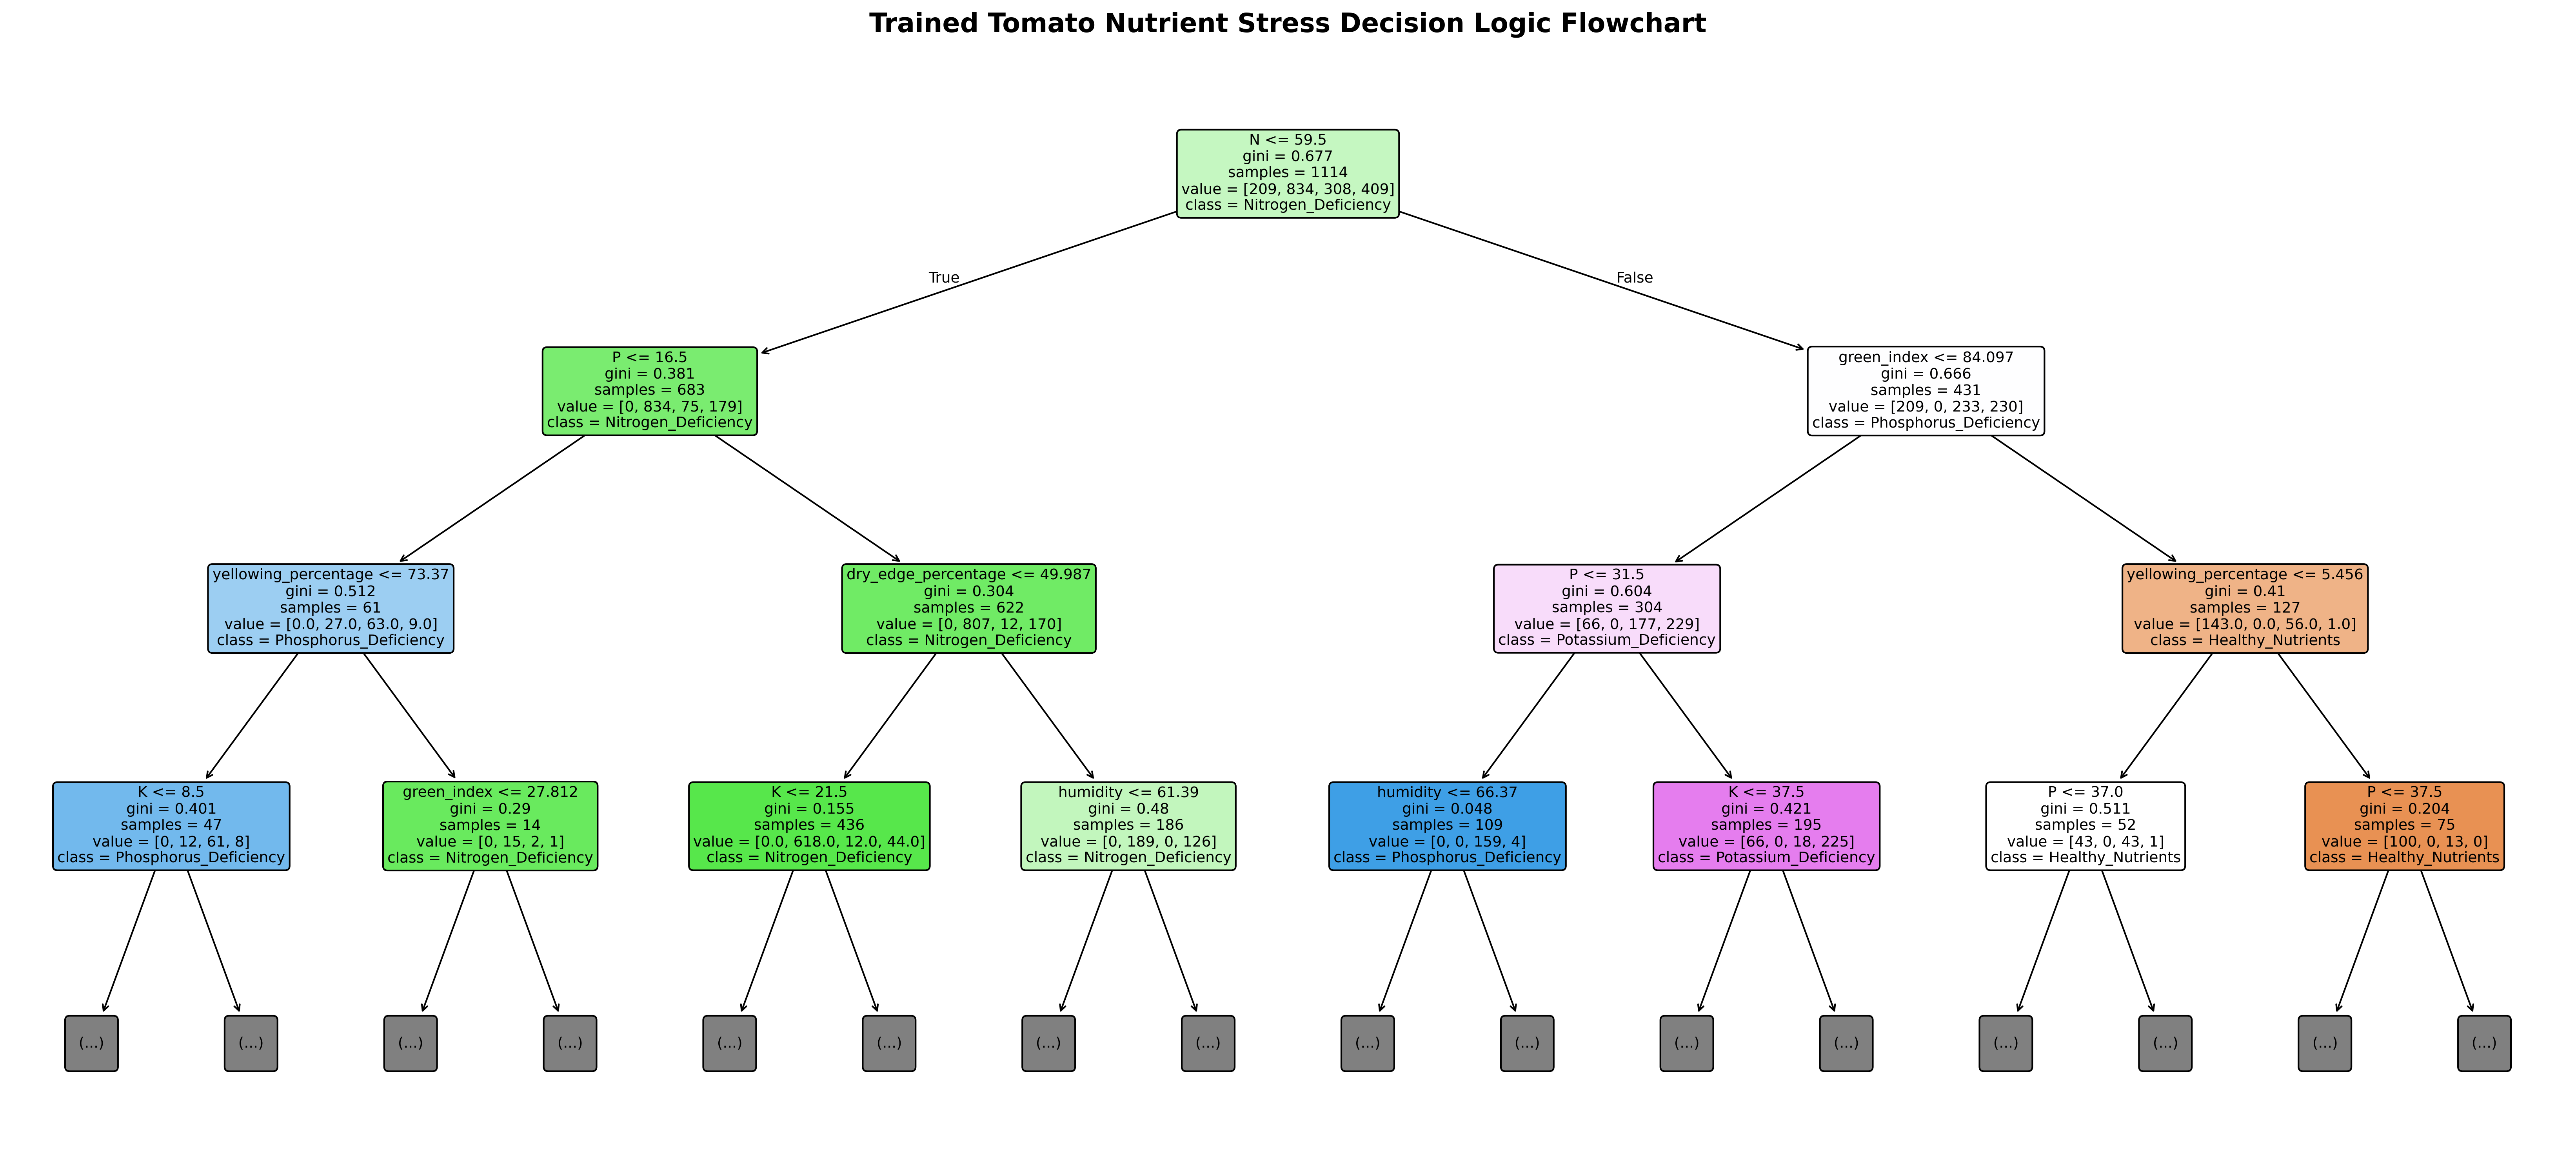

🏁 Flowchart layout successfully drawn! You can download 'tomato_decision_tree_structure.png' from your files panel.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Extract the very first decision tree (Index 0) from your trained Random Forest model
individual_tree = clf_engine.estimators_[0]

# 2. Configure a high-resolution canvas plot layout
plt.figure(figsize=(22, 10), dpi=300)

# 3. Generate the structural decision flowchart
plot_tree(individual_tree,
          max_depth=3,            # Limiting layout to 3 levels so text stays clear and readable
          feature_names=list(X.columns),
          class_names=list(clf_engine.classes_),
          filled=True,            # Color codes nodes based on their classified deficiency target
          rounded=True,           # Smooth leaf card corners
          fontsize=9)

plt.title("Trained Tomato Nutrient Stress Decision Logic Flowchart", fontsize=16, fontweight='bold', pad=20)

# 4. Save the generated flowchart chart directly to your left sidebar workspace folder
plt.tight_layout()
plt.savefig("tomato_decision_tree_structure.png", dpi=300, bbox_inches='tight')
plt.show()

print("🏁 Flowchart layout successfully drawn! You can download 'tomato_decision_tree_structure.png' from your files panel.")